In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Team members
- Marek Olejniczak 160303
- Tomasz Preś 160305
- Michał Pokładowski 160278


## Load the housing dataset

In [ ]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Overview

In [ ]:
# Shape of the dataset
df.shape

(545, 13)

In [ ]:
# Column names
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [ ]:
# Column types
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [ ]:
# Statistics of the numeric columns
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Missing values

In [ ]:
# Check for missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

All set here.

## Duplicate rows

In [ ]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

## Univarite analysis

### Numerical features

In [ ]:
df_num = df.select_dtypes(include=[np.number])
df_num

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


### Distribution

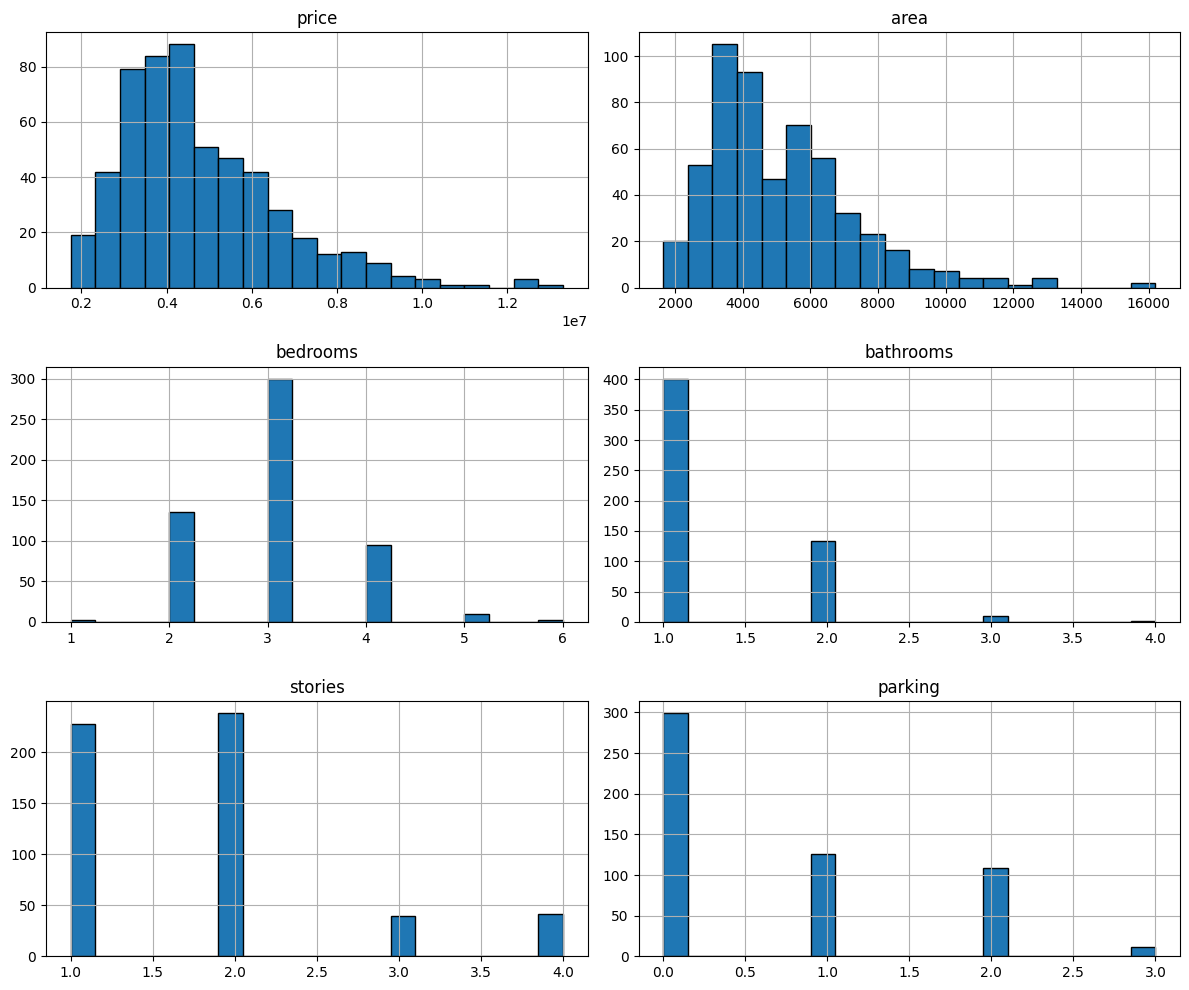

In [ ]:
# Histogram of all numeric columns
df_num.hist(figsize=(12, 10), bins=20, layout=(3, 2), edgecolor="black")
plt.tight_layout()
plt.show()

### Relation between numerical features

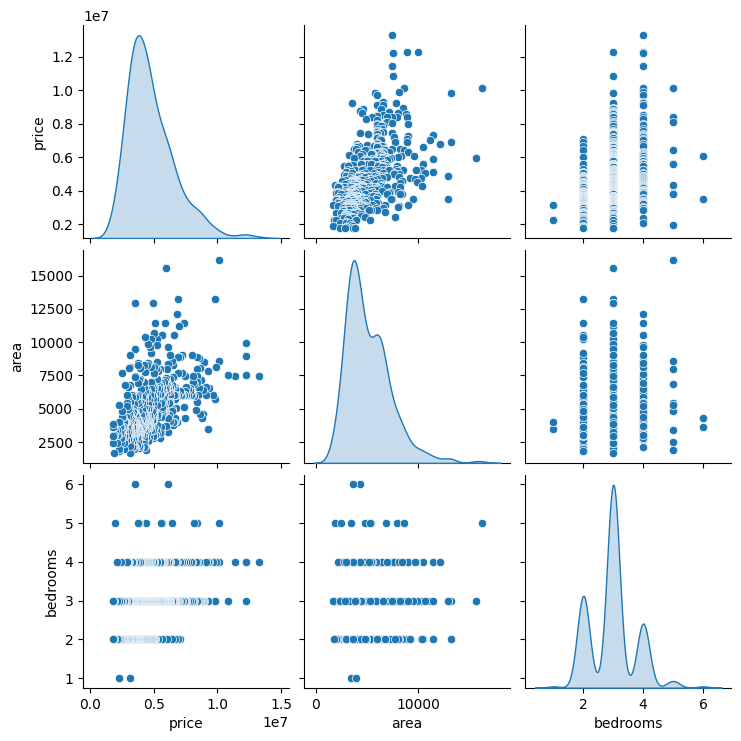

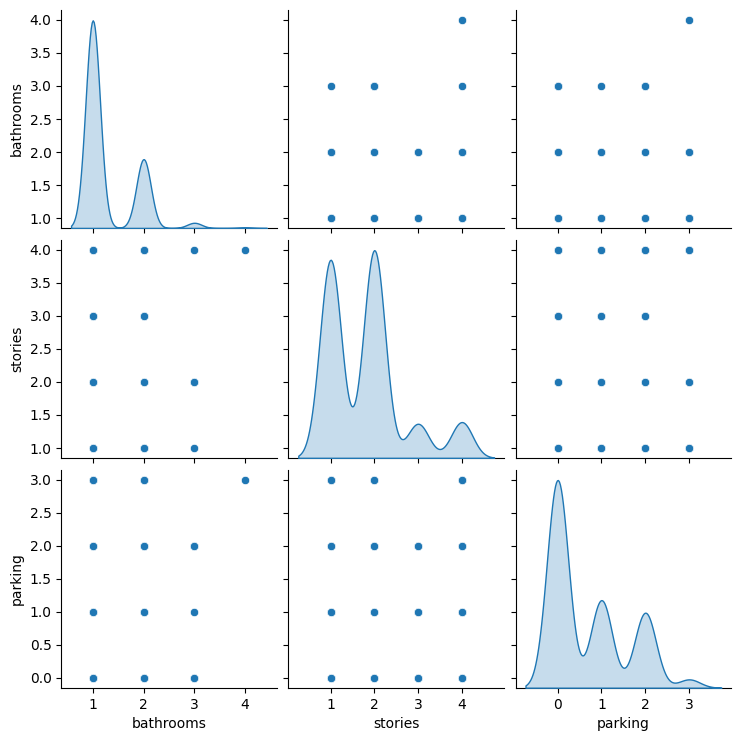

In [ ]:
for i in range(0, len(df_num.columns), 3):
    sns.pairplot(df_num.iloc[:, i : i + 3], diag_kind="kde")
plt.show()

### Boxplots

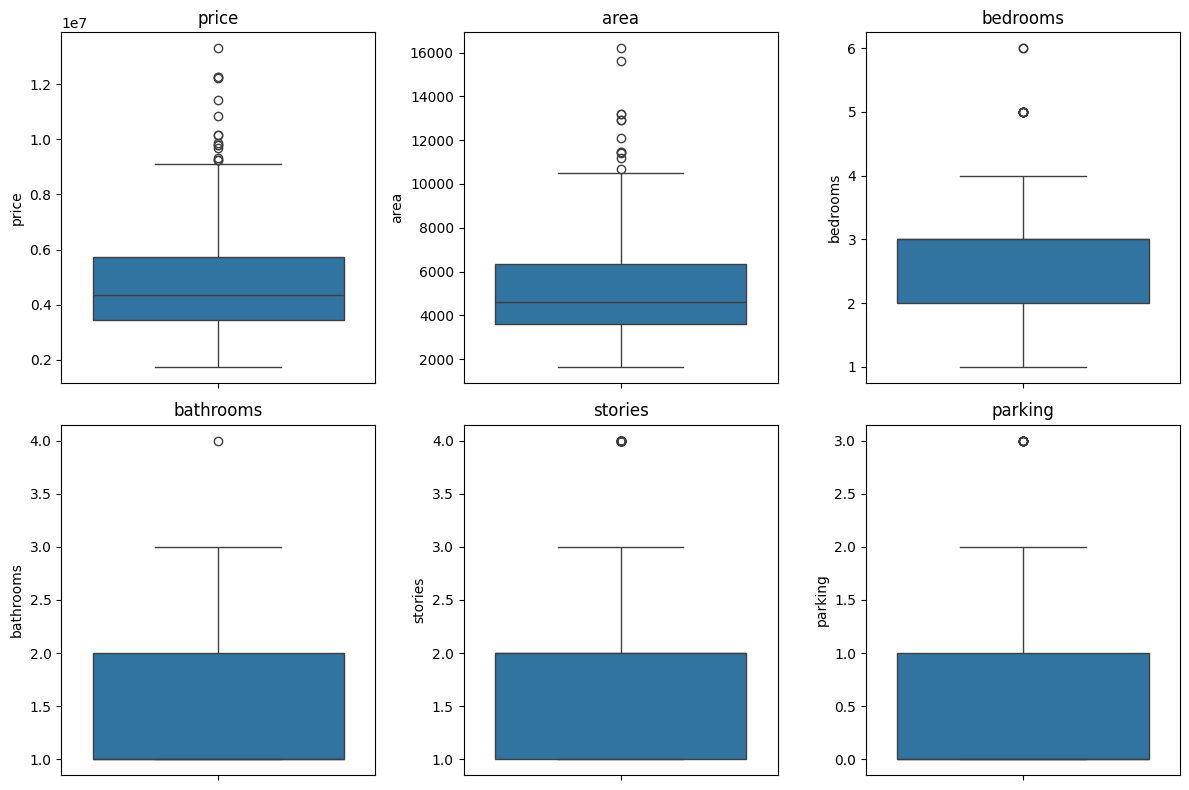

In [ ]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(df_num.columns, 1):
    plt.subplot((len(df_num.columns) + 2) // 3, 3, i)
    sns.boxplot(y=df_num[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Categorical features

In [ ]:
df_cat = df.select_dtypes(exclude=[np.number])
df_cat.head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished


/var/folders/m6/kqz4y1y10tgg9qzy55r86src0000gn/T/ipykernel_50359/1275304952.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cat, x=col, palette="viridis")
/var/folders/m6/kqz4y1y10tgg9qzy55r86src0000gn/T/ipykernel_50359/1275304952.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cat, x=col, palette="viridis")
/var/folders/m6/kqz4y1y10tgg9qzy55r86src0000gn/T/ipykernel_50359/1275304952.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cat, x=col, palette="viridis")
/var/folders/m6/kqz4y1y10tgg9qzy55r86src

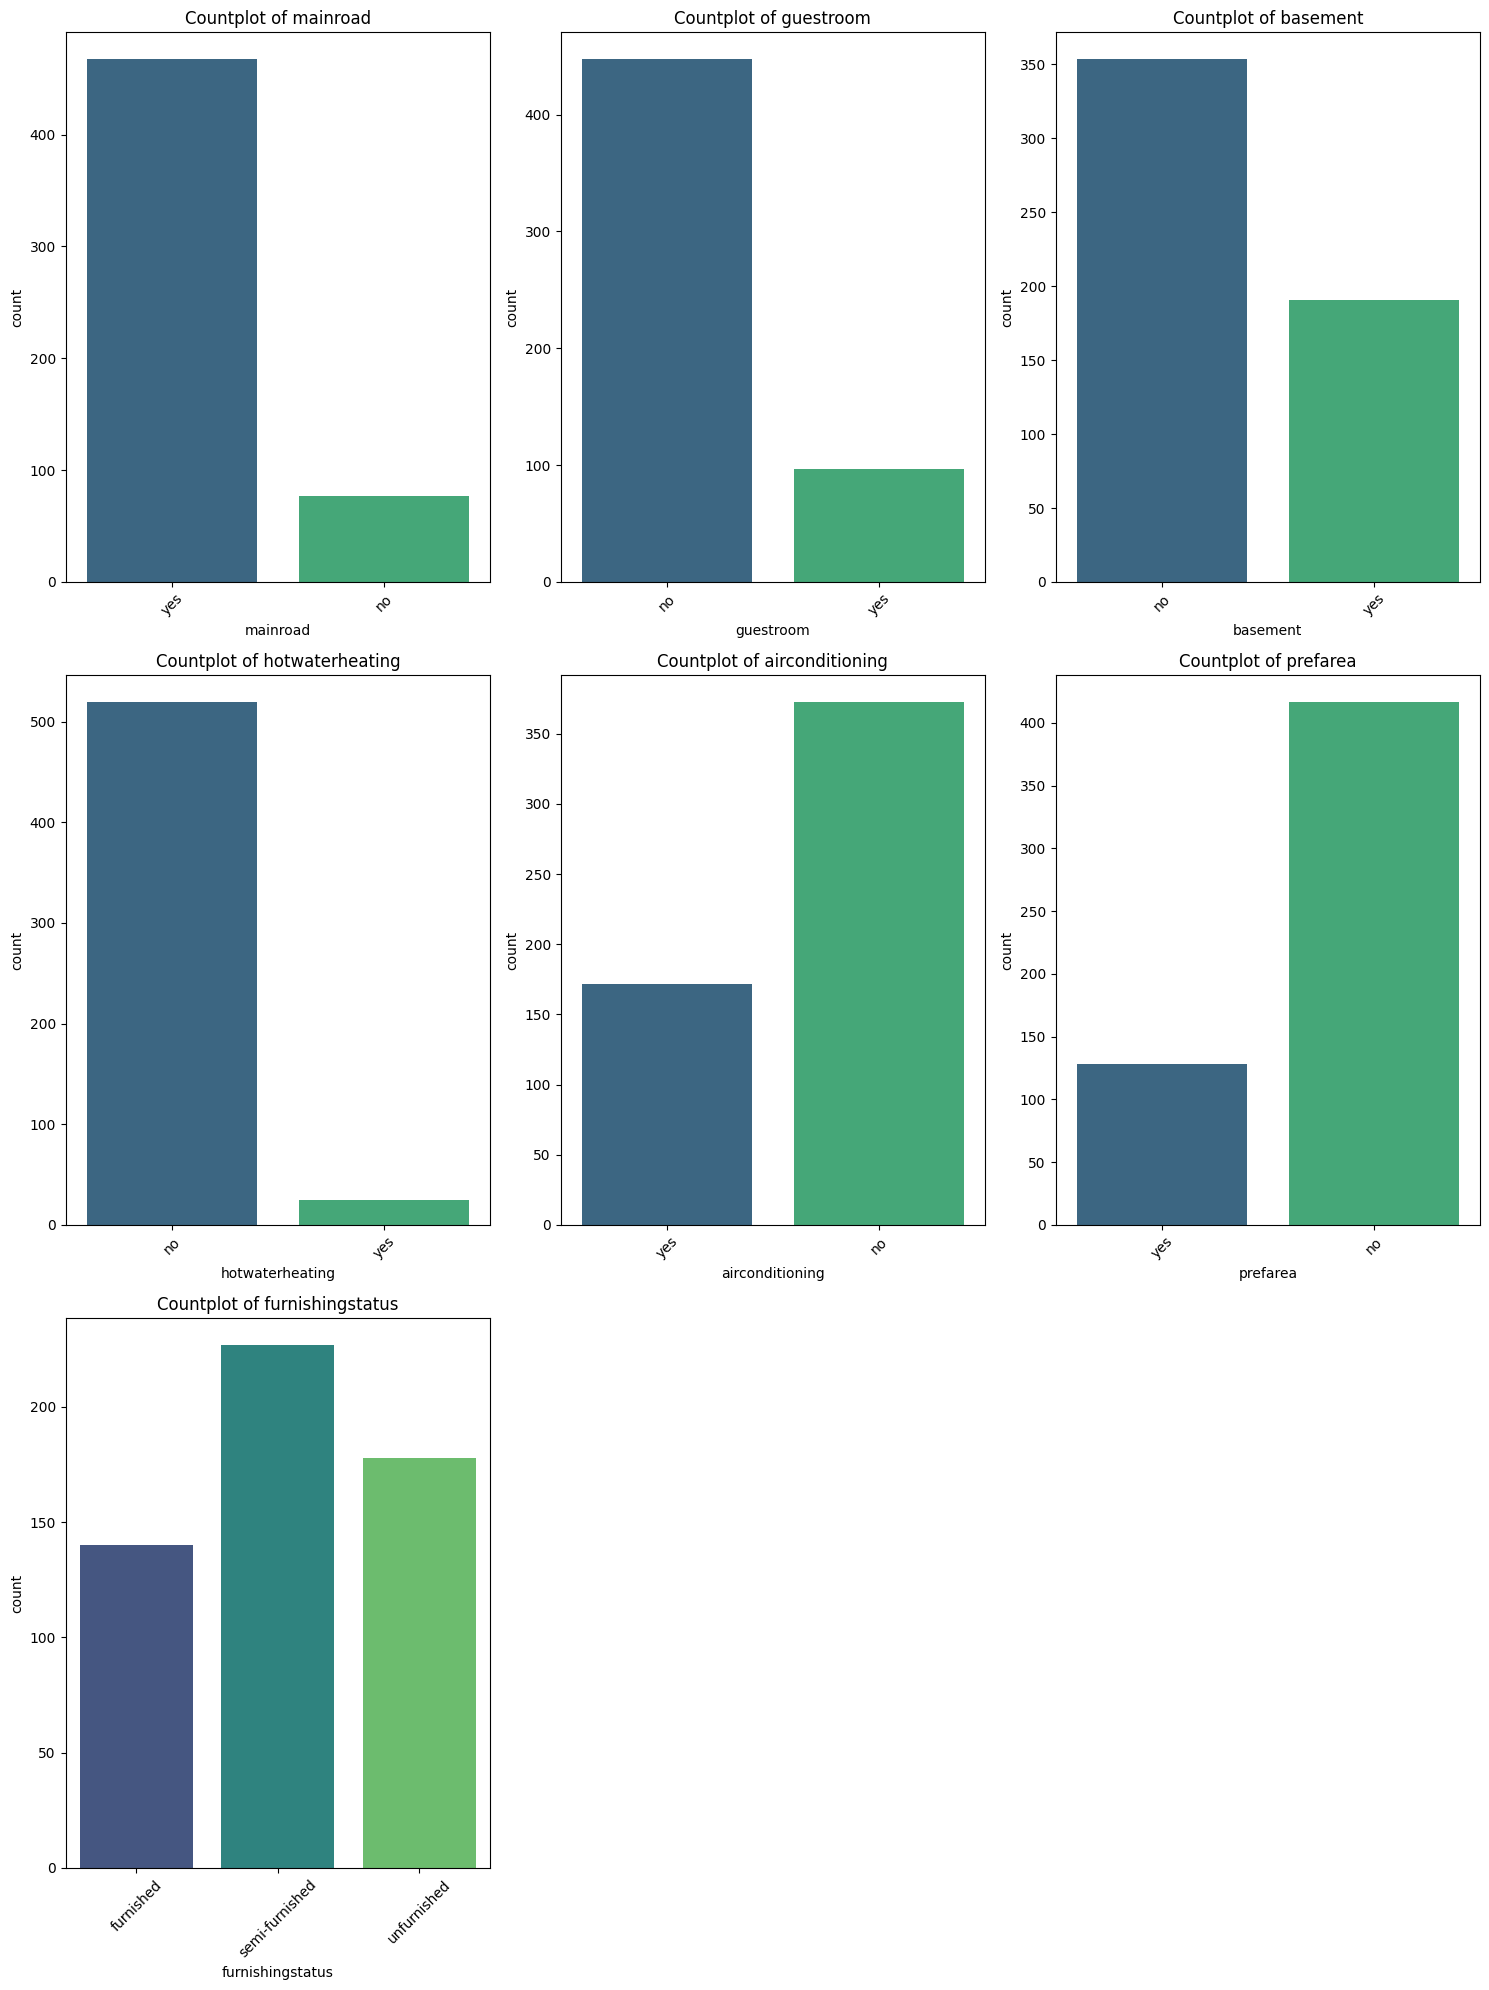

In [ ]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(df_cat.columns, 1):
    plt.subplot((len(df_cat.columns) + 2) // 3, 3, i)
    sns.countplot(data=df_cat, x=col, palette="viridis")
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analysis

In [ ]:
# Coumpute the correlation between price and other features
correlation = df_num.corr()["price"].sort_values(ascending=False)
correlation

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

#### Price vs area / bathrooms

which are two most correlated features with price.

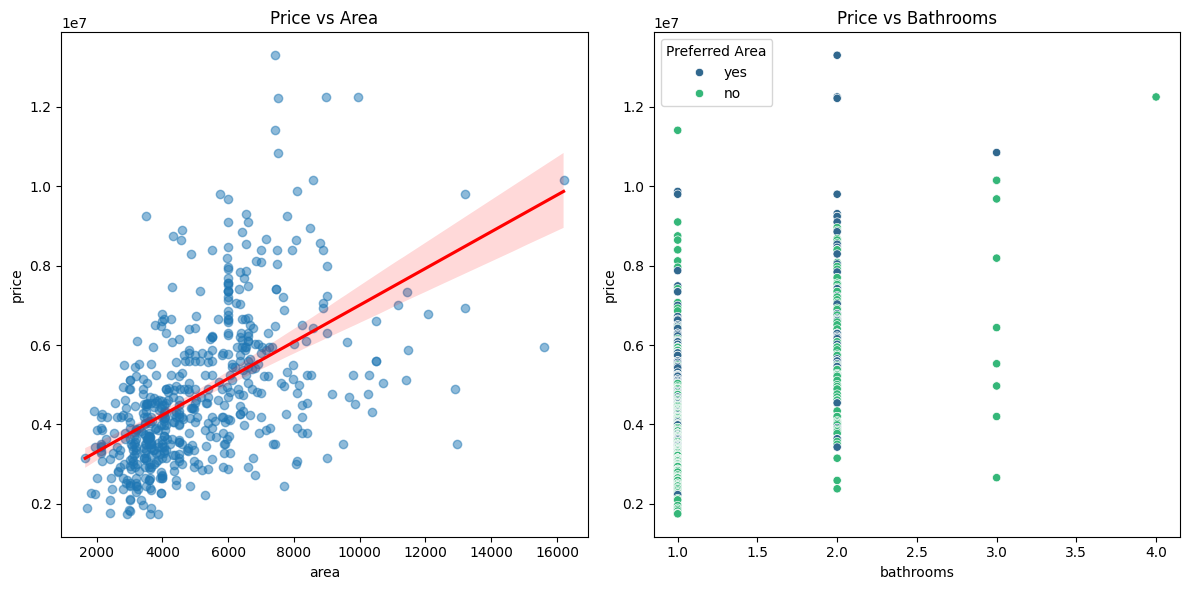

In [ ]:
plt.figure(figsize=(12, 6))

# Scatterplot for price vs area with regression line
plt.subplot(1, 2, 1)
sns.regplot(
    data=df,
    x="area",
    y="price",
    scatter=True,
    line_kws={"color": "red"},
    scatter_kws={"alpha": 0.5},
)
plt.title("Price vs Area")

# Scatterplot for price vs bathrooms
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="bathrooms", y="price", hue="prefarea", palette="viridis")
plt.title("Price vs Bathrooms")
plt.legend(title="Preferred Area")

plt.tight_layout()
plt.show()

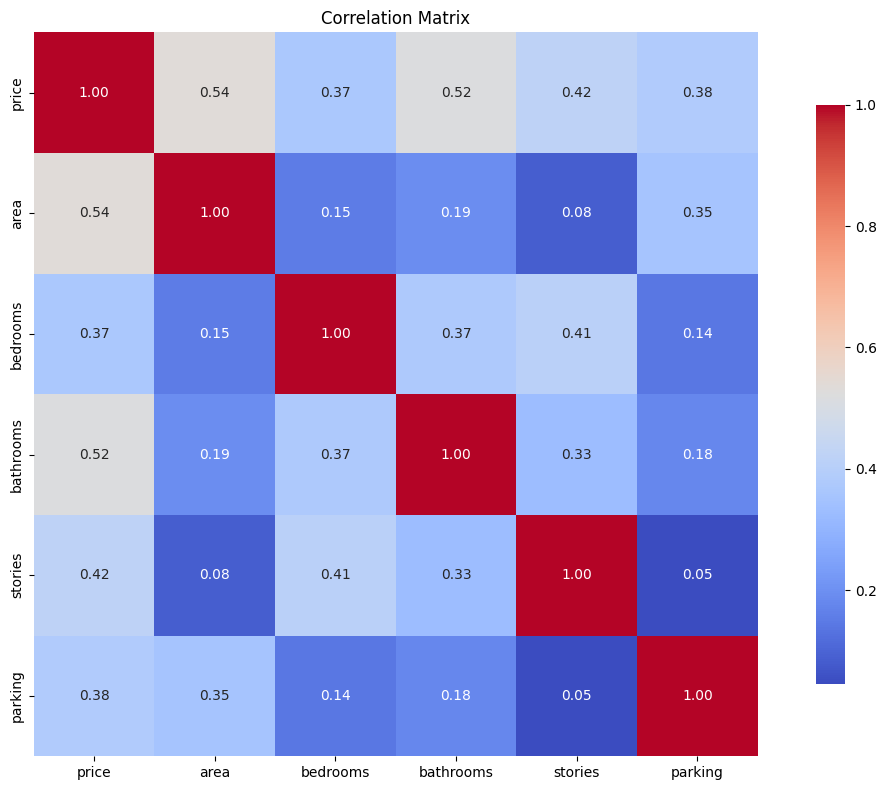

In [ ]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_num.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Mixed features

/var/folders/m6/kqz4y1y10tgg9qzy55r86src0000gn/T/ipykernel_50359/727779908.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="price", palette="viridis")
/var/folders/m6/kqz4y1y10tgg9qzy55r86src0000gn/T/ipykernel_50359/727779908.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="price", palette="viridis")
/var/folders/m6/kqz4y1y10tgg9qzy55r86src0000gn/T/ipykernel_50359/727779908.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="price", palette="viridis")
/var/folders/m6/kqz4y1y10tgg

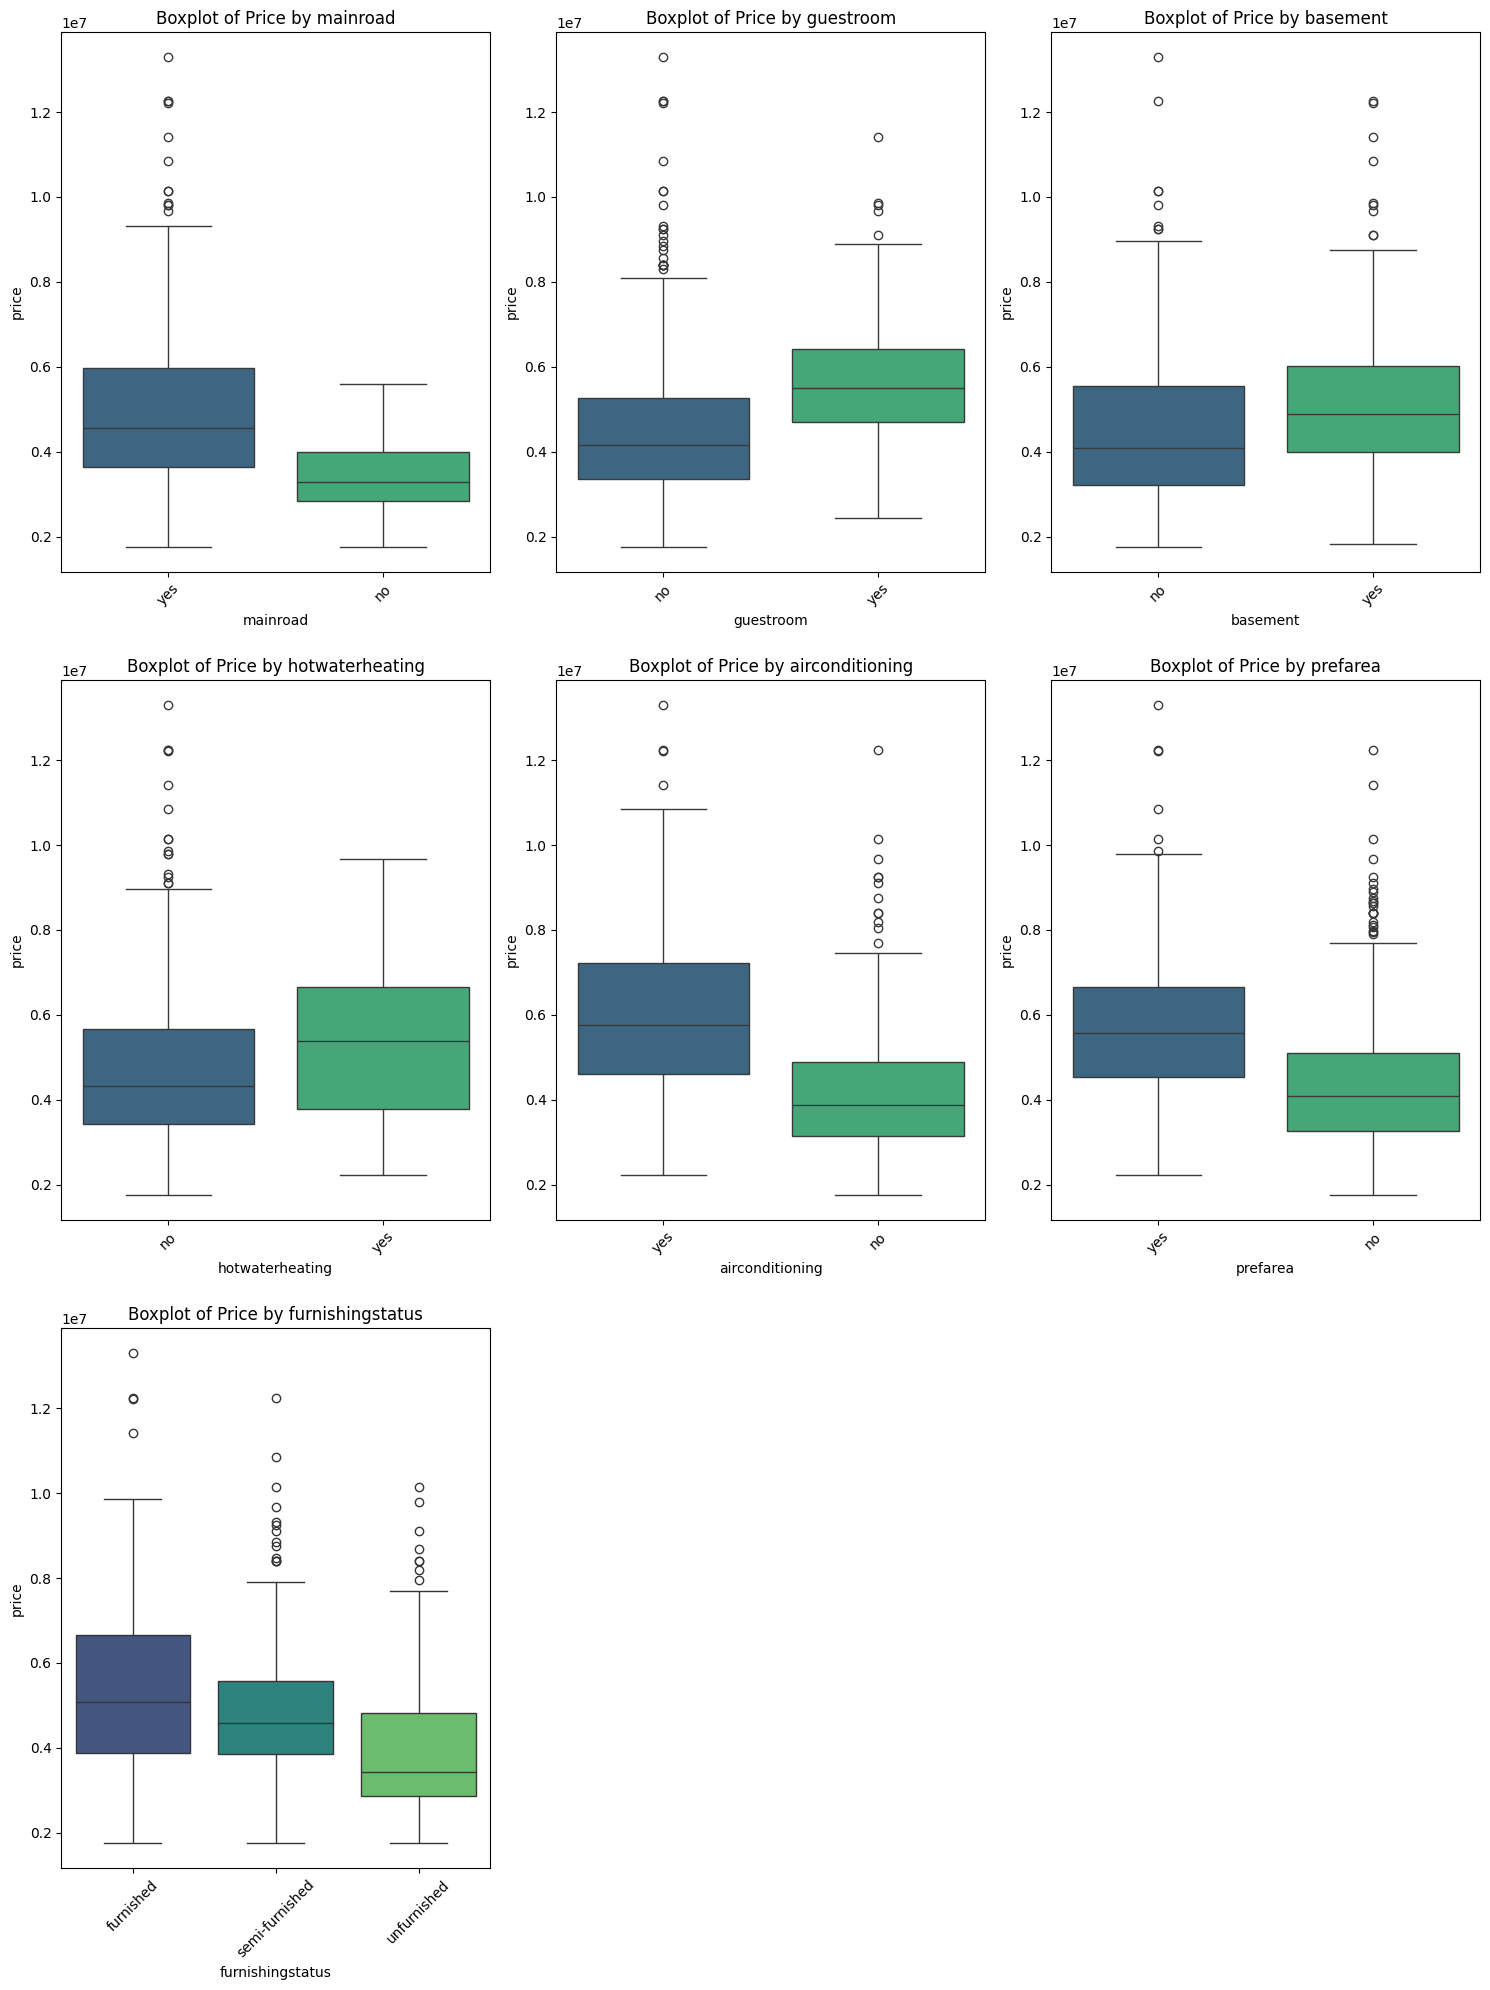

In [ ]:
# Boxplots for price divided by categorical features
plt.figure(figsize=(15, 20))
for i, col in enumerate(df_cat.columns, 1):
    plt.subplot((len(df_cat.columns) + 2) // 3, 3, i)
    sns.boxplot(data=df, x=col, y="price", palette="viridis")
    plt.title(f"Boxplot of Price by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can clearly see that every feature somehow affects the price - which is no surprise.

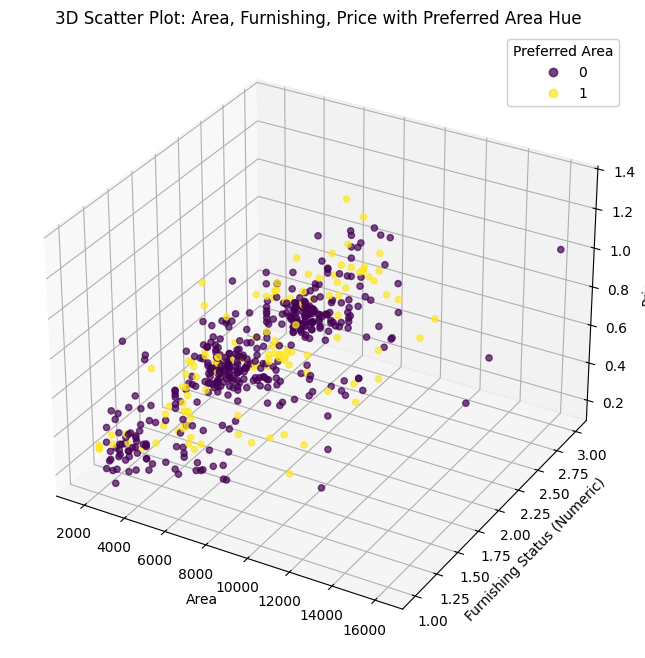

In [ ]:
# 3D scatter plot for area, furnished, and price with hue for preferred area
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Map furnishingstatus to numeric values for better visualization
furnishing_map = {"furnished": 1, "semi-furnished": 2, "unfurnished": 3}
df["furnishing_numeric"] = df["furnishingstatus"].map(furnishing_map)

# Scatter plot
scatter = ax.scatter(
    df["area"],
    df["furnishing_numeric"],
    df["price"],
    c=df["prefarea"].map({"yes": 1, "no": 0}),
    cmap="viridis",
    alpha=0.7,
)

# Labels and title
ax.set_xlabel("Area")
ax.set_ylabel("Furnishing Status (Numeric)")
ax.set_zlabel("Price")
ax.set_title("3D Scatter Plot: Area, Furnishing, Price with Preferred Area Hue")

# Add legend for preferred area
legend1 = ax.legend(*scatter.legend_elements(), title="Preferred Area")
ax.add_artist(legend1)

plt.show()

In [ ]:
import scipy.stats as stats

# Set of all categorical pairs
cat_pairs = [
    (col1, col2)
    for i, col1 in enumerate(df_cat.columns)
    for col2 in df_cat.columns[i + 1 :]
]

# Find pairs with significant correlation
significant_pairs = []
for col1, col2 in cat_pairs:
    contingency_table = pd.crosstab(df[col1], df[col2])
    chi2, p, _, _ = stats.chi2_contingency(contingency_table)
    if p < 0.01:  # Significance level
        significant_pairs.append((col1, col2))

significant_pairs

[('mainroad', 'prefarea'),
 ('mainroad', 'furnishingstatus'),
 ('guestroom', 'basement'),
 ('guestroom', 'airconditioning'),
 ('guestroom', 'prefarea'),
 ('basement', 'prefarea'),
 ('hotwaterheating', 'airconditioning'),
 ('airconditioning', 'prefarea'),
 ('airconditioning', 'furnishingstatus')]

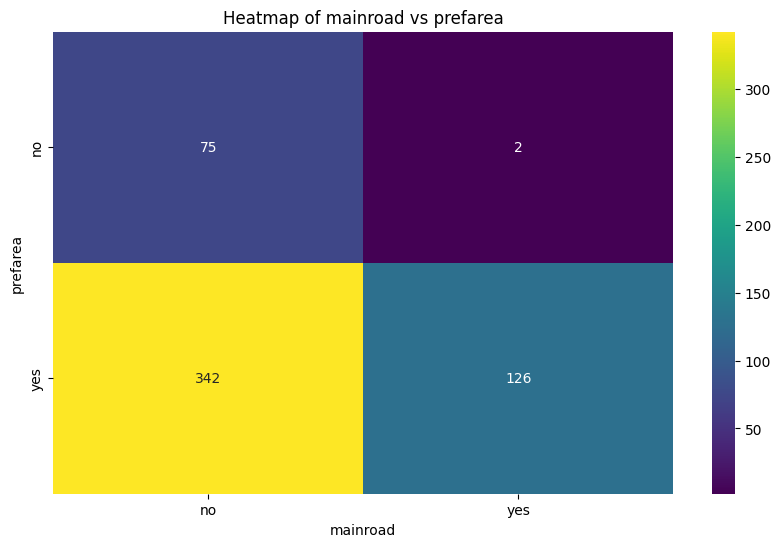

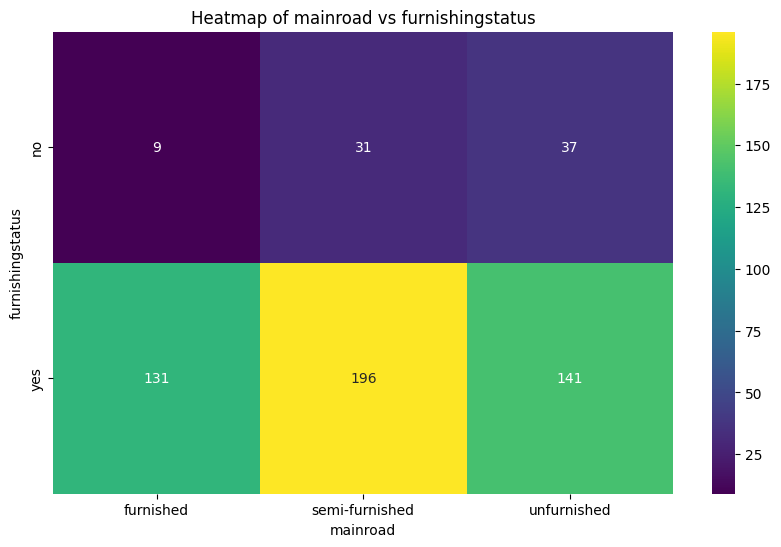

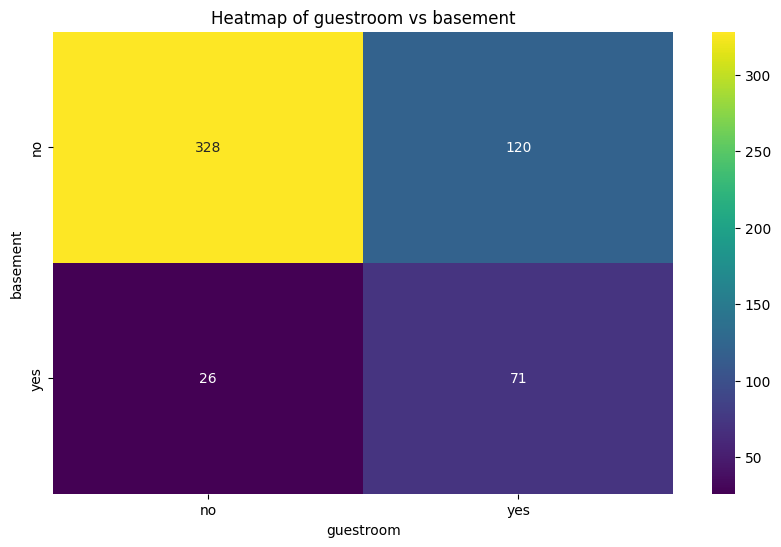

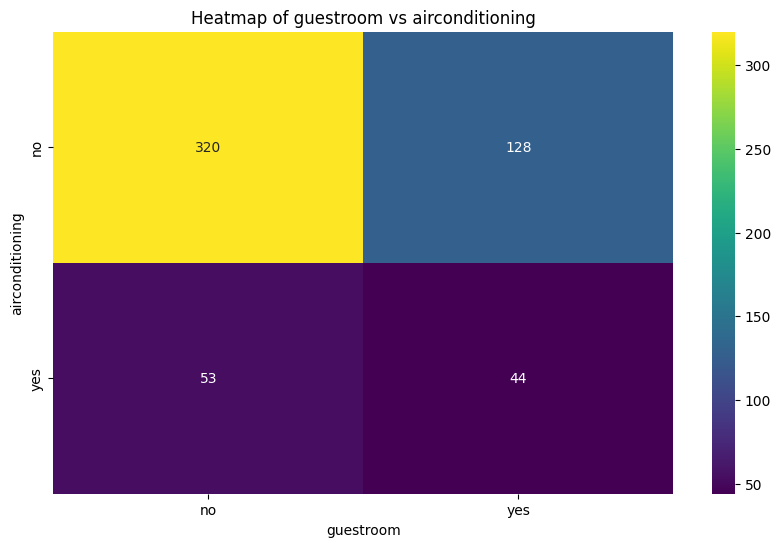

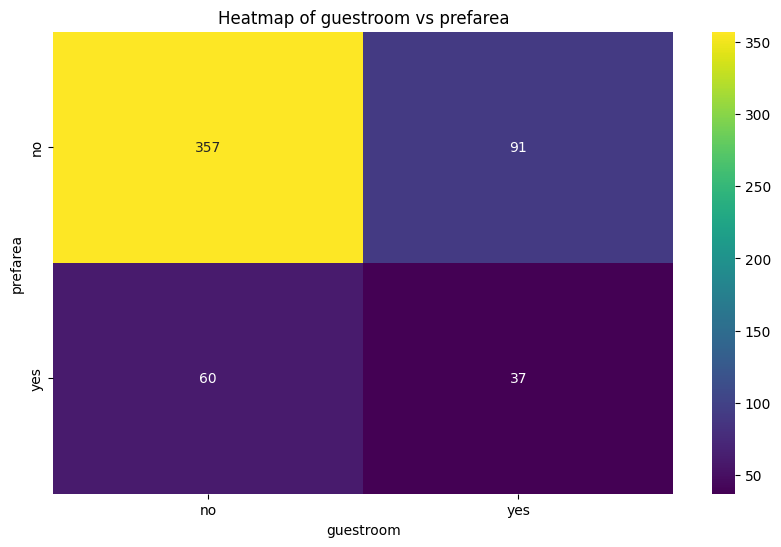

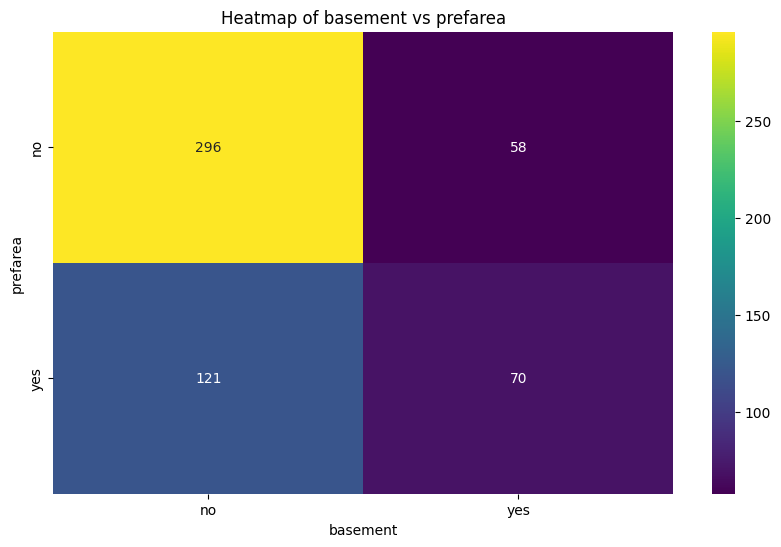

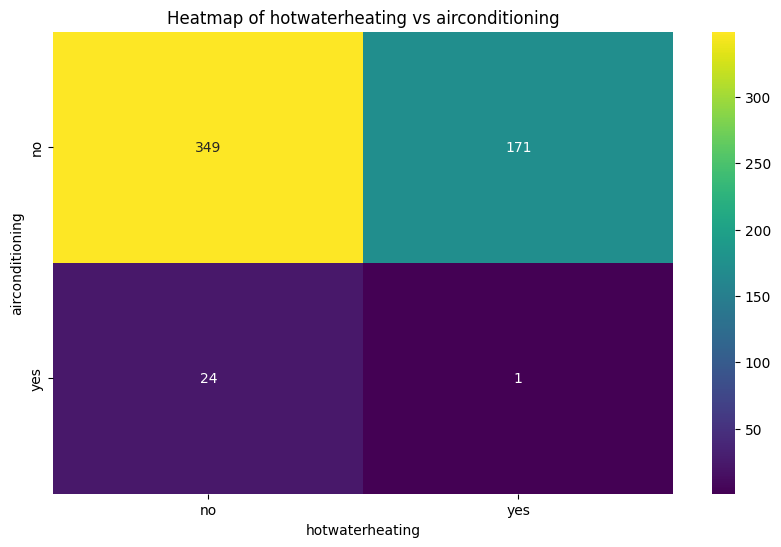

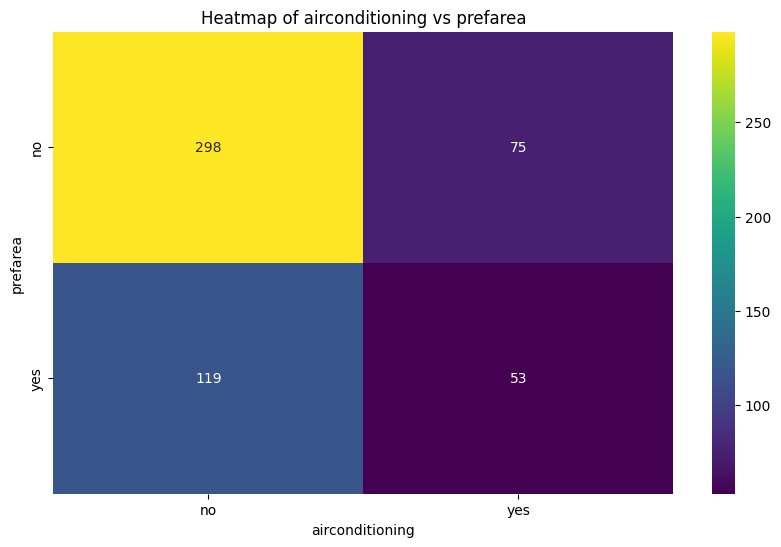

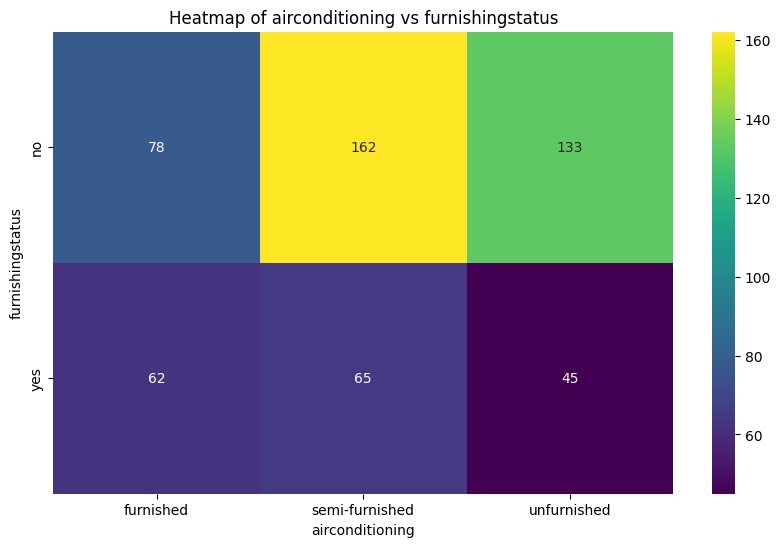

In [ ]:
# plot a heatmap for each cross-tabulation of significant categorical pairs
for col1, col2 in significant_pairs:
    plt.figure(figsize=(10, 6))
    crosstab = pd.crosstab(df[col1], df[col2])
    sns.heatmap(crosstab, annot=True, fmt="d", cmap="viridis")
    plt.title(f"Heatmap of {col1} vs {col2}")
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.show()